# 02 Exploratory Data Analysis

This notebook explores the cleaned Airbnb listings data with a narrow goal: understand the shape of the target variable and identify which factors appear most associated with listing price.

The notebook uses reusable loading and preprocessing functions from `src/` and stops short of any modeling work.

## Setup

The setup cell locates the project root, imports the reusable data utilities, and prepares a cleaned dataframe for EDA.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    """Walk upward from the current working directory until the project root is found."""
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
from src.data import load_listings, resolve_listings_path
from src.preprocess import prepare_listings_for_eda

## Load the cleaned dataframe

Set `DATA_PATH` to a local CSV path if you want to override the default raw-data location. The EDA subset below keeps only rows with observed `price`, since the target is required for the comparisons in this notebook.

In [4]:
DATA_PATH = None

resolved_path = resolve_listings_path(DATA_PATH)
raw_listings = load_listings(DATA_PATH)
listings = prepare_listings_for_eda(raw_listings)
eda_df = listings.dropna(subset=["price"]).copy()
eda_df["log_price"] = np.log1p(eda_df["price"])

numeric_columns = eda_df.select_dtypes(include="number").columns.tolist()
analysis_numeric_columns = [column for column in numeric_columns if column not in {"id", "host_id"}]
price_plot_cap = eda_df["price"].quantile(0.99)

print(f"Dataset path: {resolved_path}")
print(f"Rows in cleaned dataframe: {len(listings):,}")
print(f"Rows available for price analysis: {len(eda_df):,}")
print(f"Share of rows with observed price: {len(eda_df) / len(listings):.2%}")

Dataset path: /Users/hyl/repos/airbnb_regression/data/raw/listings.csv
Rows in cleaned dataframe: 36,353
Rows available for price analysis: 21,415
Share of rows with observed price: 58.91%


### Commentary

This notebook works from the cleaned dataframe returned by `src/` and narrows the analysis to listings with a usable target value. That keeps the plots aligned with the eventual supervised learning problem while still staying in the EDA phase.

## Target distribution: `price`

The first step is to inspect the raw scale of the target. Because Airbnb price data often contains a long right tail, the plot below caps the x-axis at the 99th percentile for readability while leaving the underlying data unchanged.

,price
count,21415.000000
mean,519.622881
std,3658.430988
min,9.000000
5%,47.000000
25%,90.000000
50%,154.000000
75%,269.000000
95%,611.300000
99%,2266.160000


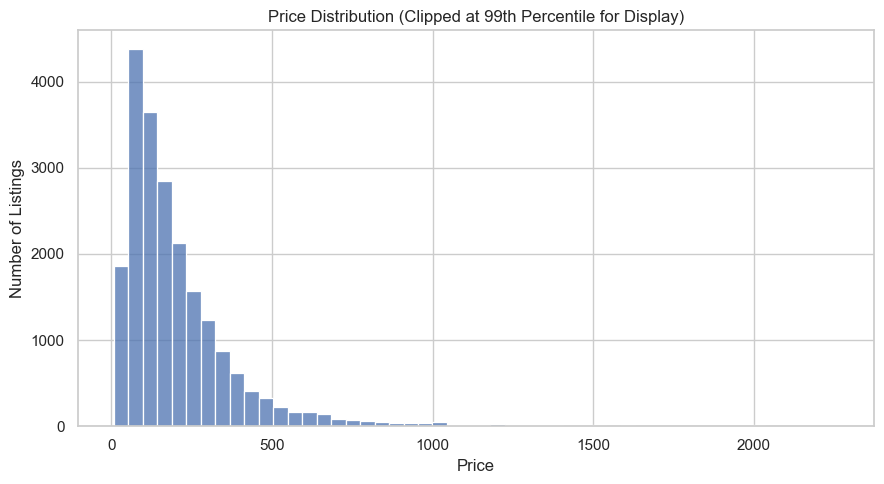

In [5]:
price_summary = eda_df["price"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(name="price")
display(price_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(eda_df.loc[eda_df["price"] <= price_plot_cap, "price"], bins=50, ax=ax)
ax.set_title("Price Distribution (Clipped at 99th Percentile for Display)")
ax.set_xlabel("Price")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.show()

### Commentary

The target distribution is strongly right-skewed, with a large concentration of listings at lower price levels and a smaller set of very expensive listings stretching the upper tail. That makes summary statistics like the mean less representative than the median and suggests a log transform is worth examining.

## Log-price distribution

A log transform is useful when the raw target is highly skewed. The comparison below checks whether `log1p(price)` produces a more stable and interpretable distribution.

,series,skew
0,price,12.422470
1,log1p(price),1.767406


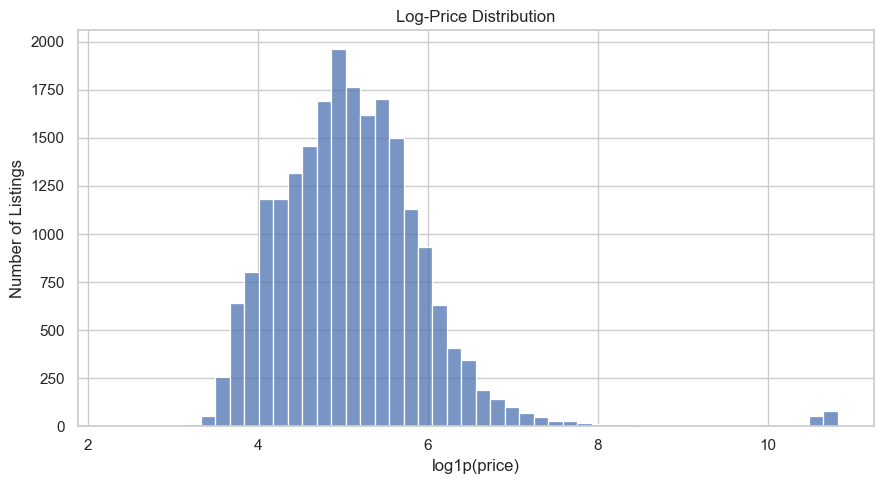

In [6]:
skew_summary = pd.DataFrame(
    {
        "series": ["price", "log1p(price)"],
        "skew": [eda_df["price"].skew(), eda_df["log_price"].skew()],
    }
)
display(skew_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(eda_df["log_price"], bins=50, ax=ax)
ax.set_title("Log-Price Distribution")
ax.set_xlabel("log1p(price)")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.show()

### Commentary

The log-transformed target is still not perfectly symmetric, but it is much less extreme than the raw price scale. That is a useful signal for the later modeling stage, where a log-target baseline may be easier to fit and interpret.

## Price by neighbourhood group

Location is one of the strongest candidate drivers of listing price, so the first comparison looks at borough-level differences.

,listing_count,median_price,mean_price
neighbourhood_group,,,
Manhattan,9558,225.0,830.551371
Brooklyn,7313,133.0,243.836456
Queens,3412,101.0,368.588511
Staten Island,314,100.0,126.515924
Bronx,818,93.0,132.992665


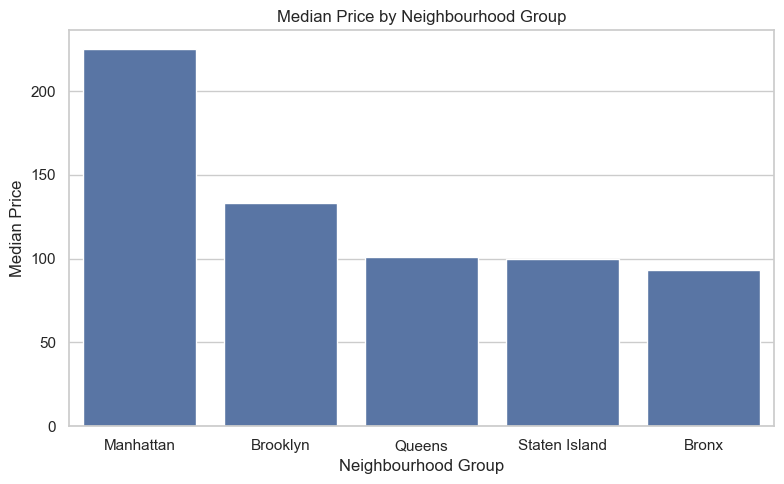

In [7]:
neighbourhood_group_summary = (
    eda_df.groupby("neighbourhood_group")["price"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .sort_values("median_price", ascending=False)
)
display(neighbourhood_group_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=neighbourhood_group_summary.reset_index(),
    x="neighbourhood_group",
    y="median_price",
    ax=ax,
)
ax.set_title("Median Price by Neighbourhood Group")
ax.set_xlabel("Neighbourhood Group")
ax.set_ylabel("Median Price")
plt.tight_layout()
plt.show()

### Commentary

The borough comparison shows that location matters materially for price. Median prices are not evenly distributed across neighbourhood groups, which suggests geographic context is likely more informative than most simple numeric listing counts on their own.

## Price by room type

Room type is another high-signal categorical variable. Because the price scale is highly skewed, the plot below compares room types on the log-price scale.

,listing_count,median_price,mean_price
room_type,,,
Hotel room,171,40000.0,34498.719298
Entire home/apt,12441,211.0,295.023632
Private room,8604,85.0,177.822408
Shared room,199,56.0,141.055276


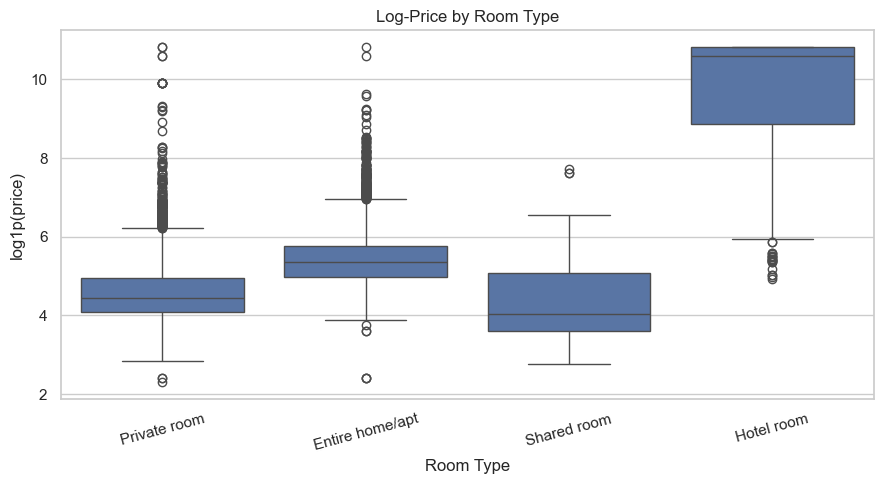

In [8]:
room_type_summary = (
    eda_df.groupby("room_type")["price"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .sort_values("median_price", ascending=False)
)
display(room_type_summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=eda_df, x="room_type", y="log_price", ax=ax)
ax.set_title("Log-Price by Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("log1p(price)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Commentary

Room type appears to separate listings more clearly than most raw numeric features. Entire homes and hotel rooms sit on a meaningfully different price scale from private and shared rooms, which makes room type a strong candidate driver in later modeling.

## Numeric summary tables

This table gives a compact view of the main numeric variables that may be relevant in later preprocessing and modeling.

In [9]:
summary_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "latitude",
    "longitude",
]
numeric_summary = eda_df[summary_columns].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
display(numeric_summary)

,count,mean,std,min,5%,25%,50%,75%,95%,max
price,21415.0,519.622881,3658.430988,9.000000,47.000000,90.000000,154.000000,269.000000,611.300000,50138.000000
minimum_nights,21415.0,26.907775,24.260443,1.000000,1.000000,30.000000,30.000000,30.000000,31.000000,729.000000
number_of_reviews,21415.0,36.775531,85.949776,0.000000,0.000000,0.000000,5.000000,38.000000,178.000000,3817.000000
reviews_per_month,15000.0,1.150749,2.308954,0.010000,0.040000,0.170000,0.445000,1.430000,4.100000,121.170000
calculated_host_listings_count,21415.0,98.280644,267.056401,1.000000,1.000000,1.000000,3.000000,25.000000,1178.000000,1178.000000
availability_365,21415.0,252.505393,108.221711,0.000000,51.000000,169.000000,283.000000,351.000000,365.000000,365.000000
number_of_reviews_ltm,21415.0,6.334345,24.228933,0.000000,0.000000,0.000000,0.000000,3.000000,39.000000,1639.000000
latitude,21415.0,40.727609,0.058258,40.504560,40.634340,40.685922,40.728943,40.763005,40.824455,40.911147
longitude,21415.0,-73.944695,0.059828,-74.251907,-74.006093,-73.983715,-73.954300,-73.922400,-73.814824,-73.713650


### Commentary

The numeric summary reinforces two themes: several variables are heavily skewed, and some operational fields have wide ranges relative to their medians. That argues for careful scaling and possibly transformed features later, but not for any immediate modeling decisions in this notebook.

## Correlation inspection for numeric columns

A correlation check is useful for a first pass, but it should be read as a linear signal only. Strong price drivers can still exist even when simple pairwise correlations look modest.

In [ ]:
correlation_matrix = eda_df[analysis_numeric_columns].corr(numeric_only=True)
correlation_with_price = correlation_matrix[["price"]].sort_values("price", ascending=False)
display(correlation_with_price)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap for Numeric Columns")
plt.tight_layout()
plt.show()

### Commentary

The numeric correlations with price are fairly weak overall, which suggests the strongest pricing signals are not simple linear relationships among the raw numeric columns. That makes the earlier categorical comparisons, especially location and room type, more important clues.

## Focused checks: what appears to drive price?

The final section uses two focused views: a more granular neighbourhood comparison and a basic minimum-night grouping. These are intended to sharpen the earlier hypothesis about what drives listing price.

In [ ]:
top_neighbourhoods = (
    eda_df.groupby("neighbourhood")["price"]
    .agg(listing_count="count", median_price="median")
    .query("listing_count >= 100")
    .sort_values("median_price", ascending=False)
    .head(12)
)

minimum_nights_summary = (
    eda_df.assign(
        minimum_nights_bin=pd.cut(
            eda_df["minimum_nights"],
            bins=[0, 2, 7, 30, 90, np.inf],
            labels=["1-2", "3-7", "8-30", "31-90", "91+"],
            include_lowest=True,
        )
    )
    .groupby("minimum_nights_bin", observed=False)["price"]
    .agg(listing_count="count", median_price="median")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=top_neighbourhoods.reset_index(),
    y="neighbourhood",
    x="median_price",
    ax=axes[0],
)
axes[0].set_title("Top Neighbourhoods by Median Price\n(Minimum 100 Listings)")
axes[0].set_xlabel("Median Price")
axes[0].set_ylabel("Neighbourhood")

sns.barplot(
    data=minimum_nights_summary.reset_index(),
    x="minimum_nights_bin",
    y="median_price",
    ax=axes[1],
)
axes[1].set_title("Median Price by Minimum Nights Bin")
axes[1].set_xlabel("Minimum Nights Bin")
axes[1].set_ylabel("Median Price")

plt.tight_layout()
plt.show()

### Commentary

The strongest visible price drivers in this first-pass EDA appear to be location and room type. More granular neighbourhood splits reveal large within-borough differences, while minimum-night requirements show some relationship to price but look weaker and less consistent than the location and room-type effects.

## EDA takeaway

At this stage, the clearest pricing signals appear to come from categorical and geographic structure rather than simple linear relationships in the raw numeric fields. That gives the next stage a clear direction: preserve and model location and room-type effects carefully, and evaluate whether a log-price target improves baseline regression performance.